# 07 - Riffs

Provide at least three visualizations that combine the preceding model data in interesting ways. These should provide insight into how features in the LIB table are related.

## Setup

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from scipy.spatial.distance import pdist
import scipy.cluster.hierarchy as sch

from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from transformers import logging as hf_logging
from ipywidgets import interact

In [56]:
OHCO = ['film_name', 'chunk_num', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:3],
    CHUNKS = OHCO[:2],
    FILMS = OHCO[:1]
)

# Import tables
LIB = pd.read_csv('tables/LIB.csv').set_index('film_name')
CORPUS = pd.read_csv('tables/CORPUS.csv').set_index(OHCO).dropna()
VOCAB = pd.read_csv('tables/VOCAB.csv')
BOW = pd.read_csv('tables/BOW.csv', index_col=[0,1])
DTM = pd.read_csv('tables/DTM.csv', index_col=0)
TFIDF = pd.read_csv('tables/TFIDF.csv', index_col=0)
TFIDF_L2 = pd.read_csv('tables/TFIDF_L2.csv', index_col=0)
THETA = pd.read_csv('tables/THETA.csv', index_col=[0, 1])
TOPICS = pd.read_csv('tables/TOPICS.csv', index_col=0)

## Riff 1 - Clustering

In [57]:
# Create a label feature in LIB that uses the following pattern: <year>: <film_name>
LIB['label'] = LIB['year'].astype(str) + ': ' + LIB['film_name']

KeyError: 'film_name'

In [ ]:
# Create a data frame called PAIRS to store the pair-wise distances among all works
PAIRS = pd.DataFrame(index = pd.MultiIndex.from_product([LIB.index.tolist(), LIB.index.tolist()])).reset_index() # Create dataframe with cartesian product of films by films
PAIRS = PAIRS[PAIRS.level_0 < PAIRS.level_1].set_index(['level_0', 'level_1']) # Remove self-pairs and duplicates
PAIRS.index.names = ['film_1', 'film_2'] # Rename index levels
PAIRS

Empty DataFrame
Columns: []
Index: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (6, 7), (6, 8), (6, 9), (6, 10), (6, 11), (6, 12), (6, 13), (7, 8), (7, 9), (7, 10), (7, 11), (7, 12), (7, 13), (8, 9), (8, 10), (8, 11), (8, 12), (8, 13), (9, 10), (9, 11), (9, 12), (9, 13), (10, 11), (10, 12), (10, 13), (11, 12), (11, 13), (12, 13)]

[91 rows x 0 columns]

In [ ]:
PAIRS['cityblock'] = pdist(TFIDF, 'cityblock')
PAIRS['cosine'] = pdist(TFIDF, 'cosine')
PAIRS['euclidean2'] = pdist(TFIDF_L2, 'euclidean')

In [ ]:
# Hierarchical clustering -- visualize combinations of distance measure from PAIRS and linkage methods
def hac(sim_method='cosine', linkage_method='complete', color_thresh=.3, figsize=(10, 10)):

    # Get the similarities among pairs
    sims = PAIRS[sim_method]
    
    # Generate the cluster tree
    tree = sch.linkage(sims, method=linkage_method)
    
    # Get labels for the leaves
    labels = LIB.label.values
    
    # Create a dendrogram from the tree
    sch.dendrogram(tree, 
        labels=labels, 
        orientation="left", 
        count_sort=True,
        distance_sort=True,
        above_threshold_color='.75',
        color_threshold=color_thresh
    )

    # Show threshhold
    ax = plt.gca()
    ax.axvline(color_thresh, c='gray', ls='--')

    # Change the appearance of ticks, tick labels, and gridlines
    plt.tick_params(axis='both', which='major', labelsize=10)    

    # Remove borders
    sns.despine(left=True, bottom=True)

    # Add title
    plt.title(f"{sim_method} + {linkage_method} ({color_thresh})", y=1.05)

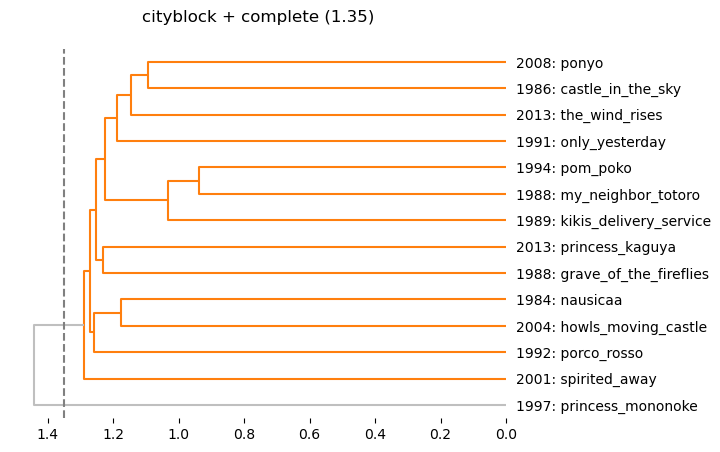

In [ ]:
hac('cityblock', 'complete', color_thresh = 1.35)

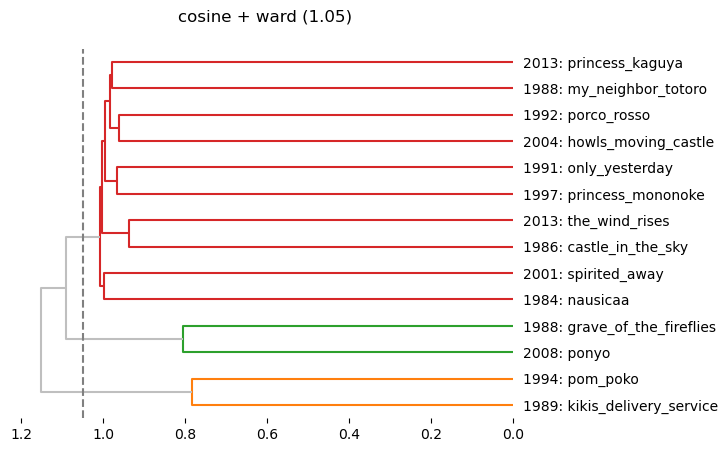

In [ ]:
hac('cosine', 'ward', color_thresh = 1.05)

In [ ]:
hac('euclidean', 'ward', color_thresh = 1.45)

KeyError: 'euclidean'

## Riff 2 - Sentiment Analysis

See code in 05_sentiment.ipynb.

![alt text](visualizations/riff2.png)

## Riff 3 - Topics

In [ ]:
# Mean topic weight per film, joined with LIB to get year and director, sorted by year
TOPIC_FILM = THETA.groupby('film_name').mean()\
    .join(LIB[['year', 'director']])\
    .sort_values('year')
TOPIC_FILM

,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,...,T12,T13,T14,T15,T16,T17,T18,T19,year,director
film_name,,,,,,,,,,,,,,,,,,,,,
nausicaa,0.034183,0.042843,0.047011,0.045629,0.048278,0.054577,0.058726,0.036827,0.038864,0.041515,...,0.059961,0.043215,0.037953,0.038073,0.082070,0.087559,0.040965,0.047062,1984,Miyazaki
castle_in_the_sky,0.032343,0.068612,0.058377,0.050520,0.044204,0.046772,0.056336,0.040189,0.046213,0.045893,...,0.040760,0.048171,0.035643,0.060814,0.049820,0.055973,0.075240,0.050408,1986,Miyazaki
my_neighbor_totoro,0.033086,0.054178,0.047914,0.059925,0.049523,0.050902,0.060730,0.045845,0.044293,0.057626,...,0.050960,0.045787,0.052339,0.044351,0.078489,0.056420,0.036305,0.038833,1988,Miyazaki
grave_of_the_fireflies,0.048406,0.045784,0.053082,0.053736,0.044848,0.071246,0.061078,0.037794,0.039570,0.049497,...,0.036546,0.068443,0.049030,0.049217,0.040315,0.057440,0.055427,0.038329,1988,Takahata
kikis_delivery_service,0.033080,0.061302,0.053003,0.043197,0.057701,0.060661,0.055065,0.056711,0.040044,0.054147,...,0.056642,0.043544,0.041049,0.042732,0.042871,0.062592,0.056295,0.039317,1989,Miyazaki
only_yesterday,0.058219,0.058379,0.058185,0.040405,0.039782,0.057980,0.045932,0.048386,0.062438,0.054282,...,0.037806,0.045422,0.055731,0.048004,0.046365,0.040579,0.046856,0.041614,1991,Takahata
porco_rosso,0.037878,0.070928,0.040726,0.041413,0.048994,0.063806,0.058614,0.044982,0.070762,0.033422,...,0.055901,0.058971,0.041683,0.048489,0.051952,0.041029,0.044878,0.055723,1992,Miyazaki
pom_poko,0.074142,0.041189,0.046360,0.049031,0.041254,0.047146,0.042825,0.052291,0.044619,0.048573,...,0.079877,0.040403,0.042289,0.050445,0.054281,0.040992,0.064428,0.038374,1994,Takahata
princess_mononoke,0.052115,0.047301,0.062977,0.064122,0.037814,0.050706,0.041841,0.052051,0.053648,0.042640,...,0.060109,0.043301,0.045332,0.049314,0.058206,0.046030,0.051161,0.046199,1997,Miyazaki


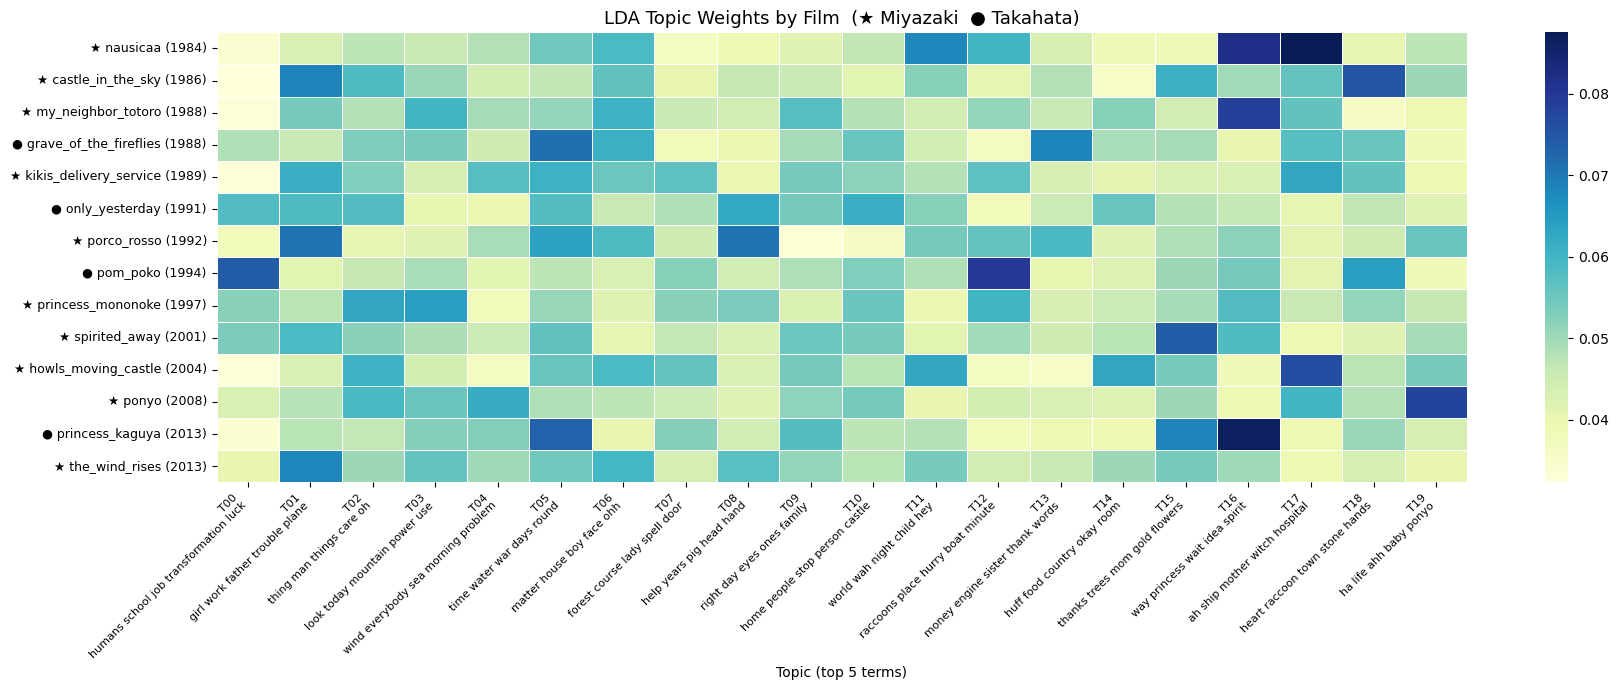

In [ ]:
# Row labels: director symbol + film name + year
row_labels = [
    f"{'★' if row.director == 'Miyazaki' else '●'} {idx} ({int(row.year)})"
    for idx, row in TOPIC_FILM.iterrows()
]

# Column labels: topic ID + top 5 terms
plot_data = TOPIC_FILM.drop(columns=['year', 'director'])
plot_data.columns = [
    f"{t}\n{' '.join(TOPICS.loc[t, 'top_terms'].split()[:5])}"
    for t in plot_data.columns
]

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(plot_data, yticklabels=row_labels, cmap='YlGnBu',
            linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('LDA Topic Weights by Film  (★ Miyazaki  ● Takahata)', fontsize=13)
ax.set_xlabel('Topic (top 5 terms)', fontsize=10)
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## Riff 4 - BERTopic

In [ ]:
FILMS = CORPUS.groupby(['film_name']).term_str.apply(lambda x: ' '.join(map(str,x)))
FILMS.head()

film_name
castle_in_the_sky         ah wah it s a gas bomb it s an attack wah ah w...
grave_of_the_fireflies    in 1945 on the night of september 21 i died wh...
howls_moving_castle       sophie we just closed the shop you ve done eno...
kikis_delivery_service    now for the weather report from northwest kari...
my_neighbor_totoro        father caramel oh thanks are you tired uh uh i...
Name: term_str, dtype: object

In [ ]:
# Convert tokens to film strings
def chunk_text(text, chunk_size=150, overlap=20):
    """Split text into overlapping word-level chunks."""
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = " ".join(words[i:i + chunk_size])
        if len(chunk.split()) >= 50:  # drop tiny tail chunks
            chunks.append(chunk)
    return chunks

In [ ]:
# Convert film strings to overlapping chunks
CHUNKS = FILMS.apply(chunk_text).apply(pd.Series).stack().to_frame('chunk_str')
CHUNKS.index.names = ['film_name', 'chunk_id']
CHUNKS

chunk_str
film_name         chunk_id                                                   
castle_in_the_sky 0         ah wah it s a gas bomb it s an attack wah ah w...
                  1         boss a girl from the sky shit wornout engines ...
                  2         s no use mama we ca nt find anything in the da...
                  3         an airship do nt you remember no hm say can i ...
                  4         the sky yes and although it s said to be a leg...
...                                                                       ...
the_wind_rises    41        mackerel bones you remembered i think it could...
                  42        take a look sure how is your bomber coming alo...
                  43        a big payload more horsepower alone wo nt be e...
                  44        m feeling much better today i m going for a wa...
                  45        what a fighter hey jiro jiro she flies like a ...

[739 rows x 1 columns]

In [ ]:
# Group by director
author_key = 'Miyazaki'
# author_key = 'Takahata'
AUTHOR_CHUNKS = CHUNKS.join(LIB).groupby('director')
X = AUTHOR_CHUNKS.get_group(author_key)

In [ ]:
# Create a count matrix
vectorizer_model = CountVectorizer(
    stop_words="english", 
    min_df=5,             
    max_df=.9,
    ngram_range=(1, 2),
)

In [ ]:
# Generate model
topic_model = BERTopic(calculate_probabilities=True, 
                       vectorizer_model=vectorizer_model, 
                       verbose=True)
topics, probs = topic_model.fit_transform(X.chunk_str)

2026-05-01 22:45:26,370 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

2026-05-01 22:45:43,474 - BERTopic - Embedding - Completed ✓
2026-05-01 22:45:43,475 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-01 22:45:55,975 - BERTopic - Dimensionality - Completed ✓
2026-05-01 22:45:55,976 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-01 22:45:56,035 - BERTopic - Cluster - Completed ✓
2026-05-01 22:45:56,039 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 22:45:56,135 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.topic_labels_

{-1: '-1_lady_witch_ah_ship',
 0: '0_ah_girl_ha_wind',
 1: '1_ah_ahh_mmm_witch',
 2: '2_mountain_humans_human_head',
 3: '3_na_welcome_gold_hmm',
 4: '4_ha_plane_fight_flying',
 5: '5_kiki_town_madam_cat',
 6: '6_sea_hot_hope_human',
 7: '7_father_granny_house_ha',
 8: '8_mr_dream_fly_world',
 9: '9_father_wonderful_mr_wind'}

In [ ]:
fig = topic_model.visualize_topics()
fig.show()

In [ ]:
htopics = topic_model.hierarchical_topics(X.chunk_str)

100%|██████████| 9/9 [00:00<00:00, 101.00it/s]


In [ ]:
print(topic_model.get_topic_tree(htopics))

.
├─ah_ha_girl_human_people
│    ├─mountain_human_humans_people_head
│    │    ├─■──mountain_humans_human_head_people ── Topic: 2
│    │    └─■──sea_hot_hope_human_promise ── Topic: 6
│    └─ah_ha_girl_ahh_na
│         ├─ah_ahh_na_spell_mmm
│         │    ├─■──na_welcome_gold_hmm_job ── Topic: 3
│         │    └─■──ah_ahh_mmm_witch_heart ── Topic: 1
│         └─ha_ah_girl_ship_wind
│              ├─■──ah_girl_ha_wind_ship ── Topic: 0
│              └─■──ha_plane_fight_flying_air ── Topic: 4
└─father_kiki_mr_granny_wonderful
     ├─mr_dream_wonderful_fly_world
     │    ├─■──mr_dream_fly_world_need ── Topic: 8
     │    └─■──father_wonderful_mr_wind_nt worry ── Topic: 9
     └─kiki_father_granny_town_black
          ├─■──father_granny_house_ha_met ── Topic: 7
          └─■──kiki_town_madam_cat_witch ── Topic: 5



In [ ]:
TOPIC[['topic_words', 'topic_weights']].sort_values('topic_weights', ascending=True)

,topic_words,topic_weights
topic_id,,
-1,"lady, witch, ah, ship, door, flying, ahh, mmm,...",0.428600
0,"ah, girl, ha, wind, ship, sky, light, everybod...",0.500588
3,"na, welcome, gold, hmm, job, uh, remember, big...",0.509153
6,"sea, hot, hope, human, promise, maybe, ow, nt ...",0.553333
4,"ha, plane, fight, flying, air, shut, fly, mone...",0.618924
1,"ah, ahh, mmm, witch, heart, lady, spell, break...",0.655780
2,"mountain, humans, human, head, people, die, si...",0.668200
5,"kiki, town, madam, cat, witch, black, tonight,...",0.672738
9,"father, wonderful, mr, wind, nt worry, catch, ...",0.684628
